**Handling Outliers in data**

1. Handling using IQR method --> used on skewly distributed data <br>
   --> 2 techniques <br>a. Trimming<br>
                    b. Capping

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('placement.csv')

In [43]:
df.sample(5)

,cgpa,placement_exam_marks,placed
374,7.34,41.0,0
155,7.84,12.0,0
459,6.62,79.0,1
240,7.25,38.0,0
577,6.85,24.0,1


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.f

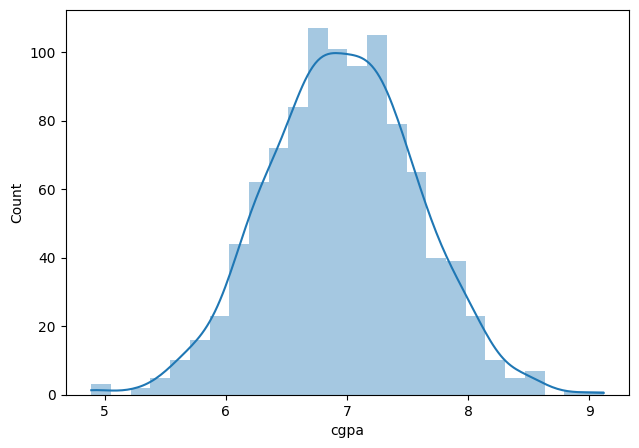

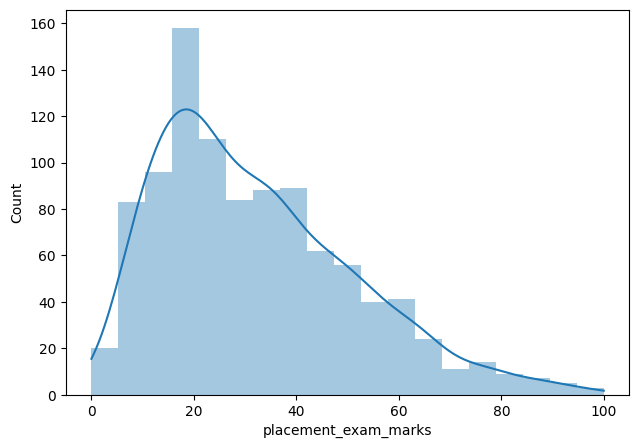

In [44]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True, edgecolor=None, alpha=0.4)

plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True, edgecolor=None, alpha=0.4)

plt.show()

In [45]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [46]:
print("Mean value of placement exam marks", df['placement_exam_marks'].mean())
print("Std deviation value of placement exam marks", df['placement_exam_marks'].std())
print("Min value of placement exam marks", df['placement_exam_marks'].min())
print("Max value of placement exam marks", df['placement_exam_marks'].max())

Mean value of placement exam marks 32.225
Std deviation value of placement exam marks 19.13082233892112
Min value of placement exam marks 0.0
Max value of placement exam marks 100.0


In [47]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

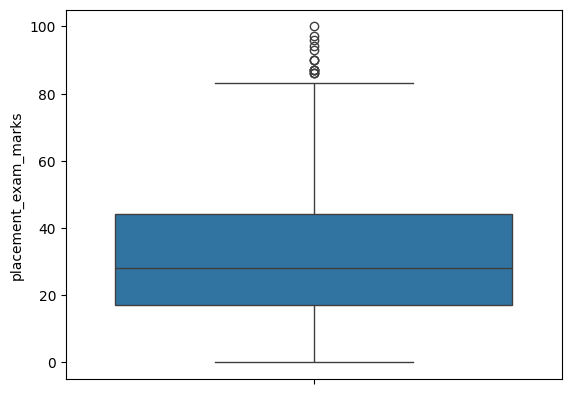

In [48]:
sns.boxplot(df['placement_exam_marks'])

In [49]:
#Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [50]:
percentile75

np.float64(44.0)

In [51]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [52]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr

In [53]:
print("Upper limit:", upper_limit)
print("Lower limit:", lower_limit)

Upper limit: 84.5
Lower limit: -23.5


**Finding Outliers**

In [54]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


**Trimming**

In [55]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [56]:
new_df.shape

(985, 3)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.f

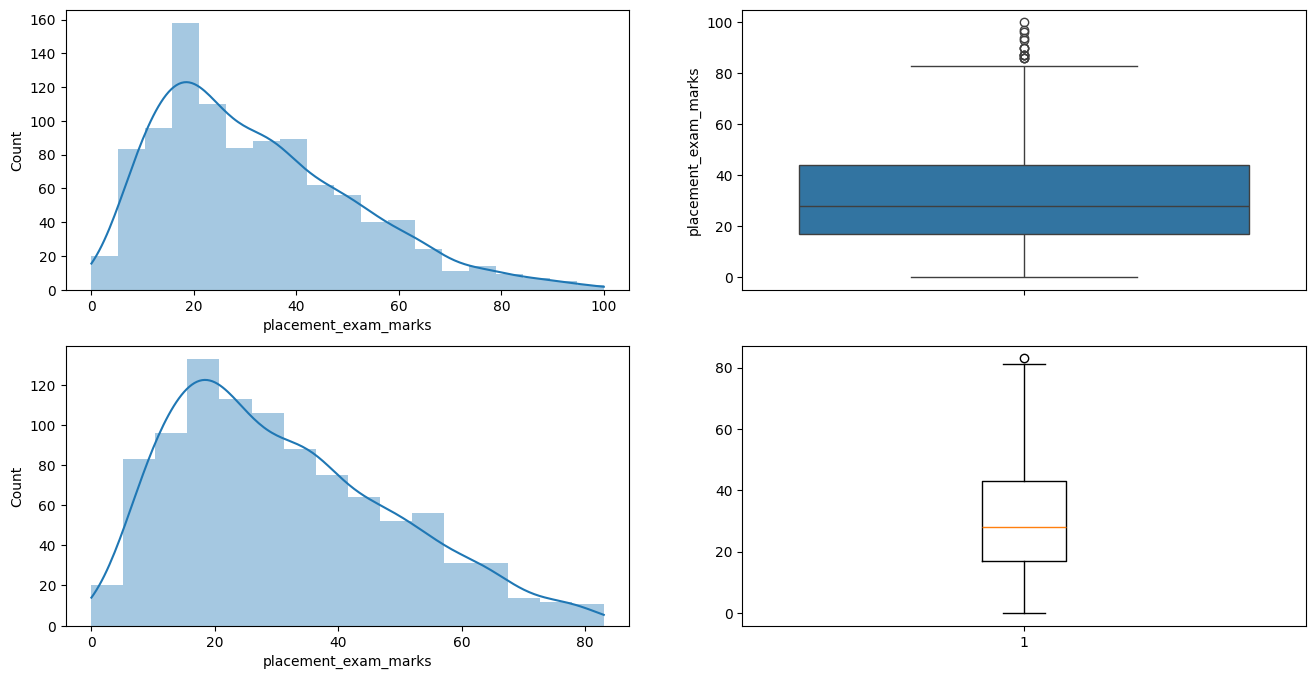

In [57]:
#Comparing

plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], edgecolor=None, alpha=0.4, kde=True)

plt.subplot(2, 2, 2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2, 2, 3)
sns.histplot(new_df['placement_exam_marks'], edgecolor=None, alpha=0.4, kde=True)

plt.subplot(2, 2, 4)
plt.boxplot(new_df['placement_exam_marks'])

plt.show()

**Capping**

In [62]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit, upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit, lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [63]:
#np.where(condition, true, false)

In [64]:
new_df_cap.shape

(1000, 3)

In [65]:
new_df_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.f

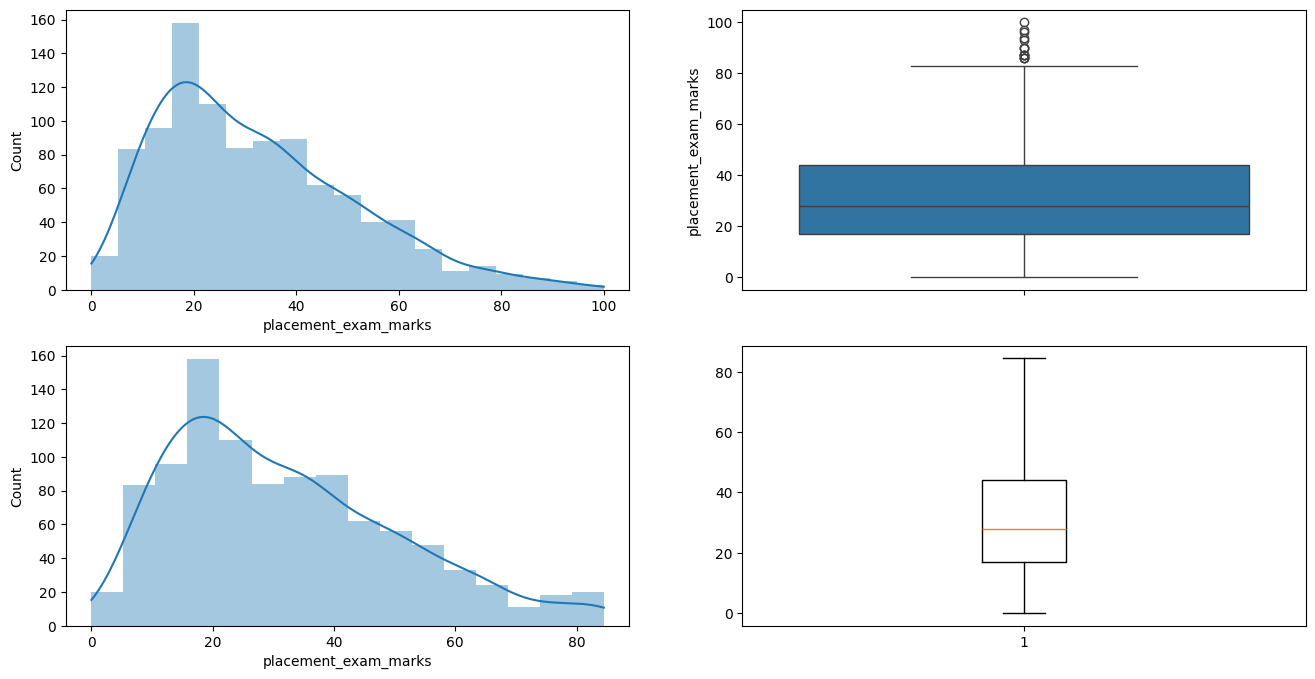

In [66]:
#Comparing

plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], edgecolor=None, alpha=0.4, kde=True)

plt.subplot(2, 2, 2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2, 2, 3)
sns.histplot(new_df_cap['placement_exam_marks'], edgecolor=None, alpha=0.4, kde=True)

plt.subplot(2, 2, 4)
plt.boxplot(new_df_cap['placement_exam_marks'])

plt.show()